# PySIAF Observation Footprint Viewer
***

## Learning Goals
- Know the requirements for generating a telescope footprint
- Create a plot of a footprint in the telescope's reference frame
- Create a plot of a footprint on the sky

## Introduction
This Notebook is a replacement for a web-based footprint viewer, and is designed as a "quick look" tool. Scientists intending to propose for Observations should use the [Astronomer's Proposal Tool (APT)](https://www.stsci.edu/scientific-community/software/astronomers-proposal-tool-apt).

Note that since [PySIAF](https://pysiaf.readthedocs.io/en/latest/) only works for HST, JWST, and Roman, you cannot generate footprints for other telescopes using this notebook.
## Imports
- `ipyaladin` plots the footprints on to a survey background
- `numpy` is not listed in the import cell, but is necessary to run the `selectSIAF` script
- `selectSIAF` is a script that uses `SIAF` to generate the telescope aperture names. Curious readers may wish to explore this file.
-  `SIAF` will translate the telescope pointing into corresponding sky footprints
-  `time` adds a pause to give Aladin time to load

In [1]:
import sys
print(sys.executable)
print(sys.version)
# %conda install -c conda-forge astropy ipyaladin regions matplotlib
# %pip install --upgrade pysiaf


/Users/richard/miniforge3/envs/jwst_phot/bin/python
3.12.13 | packaged by conda-forge | (main, Mar  5 2026, 16:51:19) [Clang 19.1.7 ]


In [2]:
from astropy.coordinates import SkyCoord
from ipyaladin import Aladin
from regions import Regions
from selectSIAF import defineApertures, getVertices, computeStcsFootprint, computeRegionFootprint
from getCatalog import gsss_stcsSearchUrl
from astroquery.mast import Mast

import matplotlib.pyplot as plt
import os
import pysiaf
import time

## Select a Telescope, Instrument, and Aperture
In order to display a fooprint, we must first select three criteria:
1. Telescope. This must be a telescope with data in [pysiaf](https://pysiaf.readthedocs.io/en/stable/index.html); at present, this is HST, JWST, and Roman.
2. Instrument. The instrument used for the observation. The valid acronyms are listed in code comments in the cell below.
3. Aperture. For a full list of valid apertures, see the instrument documentation:
    - [HST User Documentation Homepage](https://hst-docs.stsci.edu)
    - [JWST MIRI Homepage](https://jwst-docs.stsci.edu/jwst-mid-infrared-instrument) (JWST has no instrument homepage; use the site navigation to reach other instrument pages)
    - [Roman Instruments Homepage](https://roman-docs.stsci.edu/roman-instruments-home)

### Example: Roman WFI
In the code cell below, we'll set some variables to hold these three selections. In this example, we're going to plot all 18 apertures from the Roman Space Telescope's Wide Field Instrument.

For completeness, examples for HST and JWST are available but commented out.

In [3]:
# define telescope, instrument, and aperture

selectedTelescope = 'roman'
selectedInstrument = 'WFI'      # Allowed options ALL, WFI, CGI
selectedAperture = 'ALL'        # Allowed options ALL or individual apertures listed in instrument documentation

# selectedTelescope = 'hst'
# selectedInstrument = 'ALL'     # Allowed options ALL, ACS, COS, FGS, NICMOS, STIS, WFC3
# selectedAperture = 'ALL'       # Allowed options ALL or individual apertures listed in instrument documentation

# selectedTelescope = 'jwst'
# selectedInstrument = 'NIRCAM'     # Allowed options ALL, FGS, MIRI, NIRCAM, NIRSPEC, NIRISS
# selectedAperture = 'ALL'       # Allowed options ALL or individual apertures listed in instrument documentation

## Configure Apertures, Telescope Coordinate System

To simplify this Notebook, the `defineApertures` function from `selectSIAF` is essentially a lookup table, translating user-friendly instrument names into the correct corresponding apertures. 

This same function also generates the correct `V2Ref` and `V3Ref` offset angles. These V2/V3 values answer the question "what angles are there between this instrument and the line-of-sight of the telescope?". This is quite useful since, barring a catastrophic event, the instruments do not change their alignment relative to the line-of-sight.


In [4]:
# Set up aperture list and reference coordinates
apertureList, V2Ref, V3Ref = defineApertures(selectedTelescope, selectedInstrument, selectedAperture)

### Optional: Plot Footprint in Telescope Frame

Although not necessary to generate the final image, it is possible to plot the telescope apertures. We'll be plotting in a coordinate system that uses the telescope's pointing direction as (0,0); because of this, we don't need information about the celestial target or roll angle.

*Note: labels are useful for Roman WFI, but may be cluttered for other missions. You can toggle them off by setting `label=False` below.*

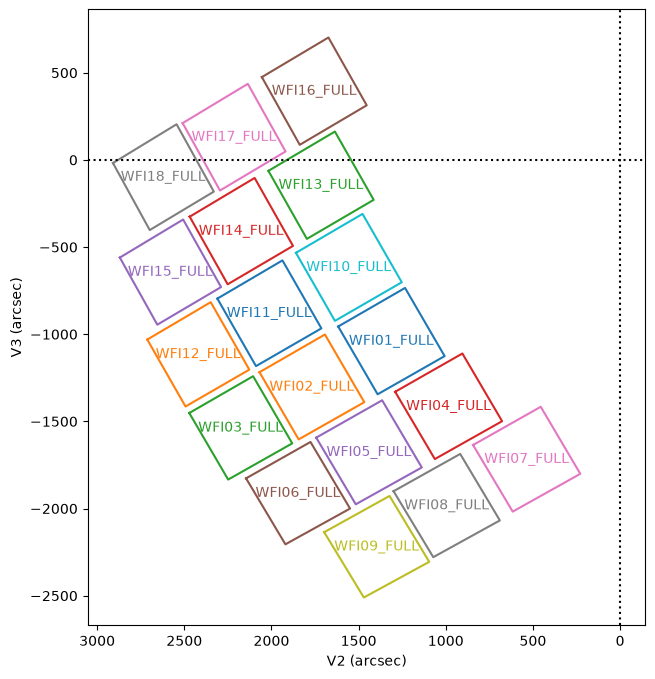

In [5]:
# OPTIONAL : set up plot of apertures (only works for QUAD, RECT, PICK aperture shapes)

# Set up the figure
plt.figure(figsize=(8, 8), facecolor='w', edgecolor='k')
plt.gca().invert_xaxis()

# iterate through apertures, then plot
for aperture in apertureList:
    # circles are not properly plotted, skip
    if aperture.AperShape != 'CIRC':
        # set labels=False to remove them
        aperture.plot(label=True)

# Add guide lines for boresight (V2, V3) = (0, 0)
plt.axvline(color='k', linestyle=":")
plt.axhline(color='k', linestyle=":")

# Display the plot
plt.show() 

## Specifying a Target

For convenience, we can use the `resolve_object` function from the MAST module of `astroquery` to get our coordinates. This isn't necessary if you already know the exact coordinates; however, you should note that the additional formatting steps below are necessary for `PySIAF` and `Aladin` to understand your query.

In [6]:
# Resolve the target name to coordinates
coords = Mast.resolve_object("coma cluster")
coords

# or... Specify RA, Dec coordinates (This happens to be Arp 244)
# coords = SkyCoord(180.46, -18.89, frame='icrs', unit='deg')

<SkyCoord (ICRS): (ra, dec) in deg
    (194.93502, 27.91246)>

Using MAST to resolve our target returns a [skycoord](https://docs.astropy.org/en/stable/coordinates/) object. We need two different formats to satisfy `pysiaf` and `Aladin`. `pysiaf` requires separate ra/dec objects, while `Aladin` is looking for a string containing both.

Fortunately, `skycoord` objects are flexible enough to handle both of these requirements with straightforward calls:

In [7]:
import astropy.units as u

# get the values for SIAF
targetRa = coords.ra + 1 * u.arcmin
targetDec = coords.dec - 1 * u.arcmin

coords_str = coords.to_string()

# print out these values to check their conversions
print(f"RA:     {targetRa}\nDEC:    {targetDec}\nString: {coords_str}")

RA:     194.9516866666667 deg
DEC:    27.895793333333334 deg
String: 194.935 27.9125


There's rounding in our RA/Dec as a result of our `to_string()` call. As we'll see later on, we only need this string to point the Aladin viewer at the right section of the sky; a little bit of rounding won't affect our view much.

## Telescope Position Angle

The last variable we need to set before using `pysiaf` is the telescope position angle. From the docstring of the `attitude_matrix` function:
>Position angle of V3 axis at nu2,nu3 measured from North to East (default unit is degree)

In plain English, this is the telescope roll angle; with the telescope fixed on the target, it rotates around its V1 (line-of-sight) axis. Modifying this value will cause the footprints to "roll" around the target.

In [8]:
# can be any value between 0 and 360
telescopePositionAngle = 230

## Generate The Attitude Matrix

At this point, we've generated footprints in the telescope's field of view. Now, we need to translate this into a view on the sky, in RA/Dec coordinates. This is handled by the `attitude_matrix` function, which is doing some matrix multiplication behind the scenes.

In [9]:
# Set telescope pointing matrix: "attitude matrix"
attmat = pysiaf.utils.rotations.attitude_matrix(V2Ref, V3Ref, targetRa, targetDec, telescopePositionAngle)

## Calculate Sky Regions

The final step is to convert to the [IVOA Space-Time Coordinate Metadata Linear String Implementation (STS-C)](https://ivoa.net/documents/STC-S/). Do not fear this verbose name; it's a method of standardizing footprints in string formats. The specifics depend on the particular shape used. For the curious, the `computeStcsFootprint` function from `selectSIAF` is what calcuates these strings in this Notebook.

Since `Aladin` knows how to parse this format, it will be able to plot it on a sky background of our choice. It is not particularly human readable, but we'll print it out anyway.

In [10]:
# Loop through aperture list  (only works for QUAD, RECT, CIRC aperture shapes)
# Transform to sky coordinates, build footprints for passing to Aladin
combinedSregion = ''
for apertureSiaf in apertureList:
    apertureSiaf.set_attitude_matrix(attmat)
    xVertices, yVertices = getVertices(apertureSiaf)
    
    # Skip PICK which do not have vertices (HST/FGS is only instrument affected)
    if (xVertices is not None and yVertices is not None):
        skyRa, skyDec = apertureSiaf.idl_to_sky(xVertices, yVertices)
        apertureSregion = computeStcsFootprint(apertureSiaf, skyRa, skyDec)
        combinedSregion += apertureSregion
        
print('\n'+combinedSregion)


POLYGON ICRS 194.95253617 27.92206796 194.97674402 27.80095073 195.11669155 27.82236909 195.09191375 27.94329277 POLYGON ICRS 194.92442522 28.06493658 194.94818662 27.94645314 195.08741740 27.96763903 195.06286753 28.08591013 POLYGON ICRS 194.89930641 28.19244449 194.92255104 28.07687439 195.06090826 28.09781499 195.03667964 28.21315339 POLYGON ICRS 195.10876716 27.91931059 195.13360894 27.79799474 195.27308181 27.81861439 195.24776216 27.93956454 POLYGON ICRS 195.08077791 28.06268020 195.10544655 27.94391301 195.24431064 27.96408504 195.21893671 28.08247697 POLYGON ICRS 195.05575087 28.19002365 195.08013552 28.07409723 195.21821084 28.09384244 195.19292940 28.20939640 POLYGON ICRS 195.27247425 27.87844148 195.29775155 27.75662369 195.43608593 27.77658880 195.41048699 27.89788250 POLYGON ICRS 195.24455176 28.02284437 195.26997127 27.90330997 195.40787538 27.92261869 195.38190464 28.04162051 POLYGON ICRS 195.22105548 28.14956931 195.24647937 28.03262176 195.38374491 28.05132798 195.357

### Optional: Create DS9 region file with footprints

Although not necessary to generate the final image, it is possible to write the footprints to a DS9 region file. Here, we'll create a file called `regionTest.reg`.

In [ ]:
# OPTIONAL build same footprints for creating a DS9 region file

regionList = []
for i in range(len(apertureList)):
    apertureSiaf = apertureList[i]
    apertureSiaf.set_attitude_matrix(attmat)
    xVertices, yVertices = getVertices(apertureSiaf)
    
    # Skip PICK which do not have vertices
    if (xVertices is not None and yVertices is not None):
        skyRa, skyDec = apertureSiaf.idl_to_sky(xVertices, yVertices)
        apertureRegion = computeRegionFootprint(apertureSiaf, skyRa, skyDec)
        regionList.append(apertureRegion)
        
# Provide a writeable file location on your system
regionFile = 'regionTest.reg'
if os.path.isfile(regionFile):
    os.remove(regionFile)
combinedRegion = Regions(regionList)
combinedRegion.write(regionFile)

In [ ]:
# import anywidget
# import ipywidgets
# import ipyaladin
# import jupyterlab_widgets

# print("anywidget:", anywidget.__version__)
# print("ipywidgets:", ipywidgets.__version__)
# print("ipyaladin:", ipyaladin.__version__)
# print("jupyterlab_widgets:", jupyterlab_widgets.__version__)

In [ ]:
# %pip install --upgrade anywidget ipywidgets jupyterlab_widgets ipyaladin

## Initialize Aladin
Let's start the Aladin viewer. We're loading a default field of view of 1 degree, with DSS as the background survey. Depending on your screen size, you may need to adjust the `height` (in pixels) to get the best view.

**NOTE:** The footprint will not be displayed in the rendered HTML. Please download and run it locally, or use [TIKE](https://timeseries.science.stsci.edu).

In [ ]:
aladin = Aladin(height=1200, fov=1, survey="P/DSS2/color", target=coords_str)
aladin

In [32]:
# Pause for 2 seconds to give Aladin time to load the viewer
# Necessary when using "Run All Cells", or even just hitting 'shift+enter' fast enough
time.sleep(2)

# Add the footprint with a hexcode for the color; you can also enter, e.g. "green"
# aladin.add_overlay_from_stcs(combinedSregion, color="cyan")  # This is simulated Roman footprint
aladin.add_overlay_from_stcs(hst_stcs, color="gold")  # This is actual Coma HST footprint
aladin.add_overlay_from_stcs(combined_stcs, color="red")  # This is actual JWST footprint (NIRCam)

/var/folders/_d/2vszj0nd6532d6knr4c9lnrw0000gn/T/ipykernel_2592/707180699.py:7: DeprecationWarning: 'add_overlay_from_stcs' is deprecated, use 'add_graphic_overlay_from_stcs' instead. This will be removed in version 1.0.0.
  aladin.add_overlay_from_stcs(hst_stcs, color="gold")  # This is actual Coma HST footprint
/var/folders/_d/2vszj0nd6532d6knr4c9lnrw0000gn/T/ipykernel_2592/707180699.py:8: DeprecationWarning: 'add_overlay_from_stcs' is deprecated, use 'add_graphic_overlay_from_stcs' instead. This will be removed in version 1.0.0.
  aladin.add_overlay_from_stcs(combined_stcs, color="red")  # This is actual JWST footprint (NIRCam)


Done! The roman footprints are now visible in the Aladin window.

Done! The footprint is now visible in the Aladin window.

## Add a Catalog

You can also overlay catalog sources onto the viewer. Clicking on these sources will show their names, RA/decs, and any other information included in the catalog.

In [ ]:
# Optional Retrieve catalog sources from MAST that are within footprint and overlay them
# Supported catalogs : 'GSC11', 'GSC243', 'GSC30', '2MASS', 'GAIADR3'  

#selectedCatalog = 'GSC11'
#selectedCatalog = 'GSC243'
#selectedCatalog = 'GSC30'
#selectedCatalog = '2MASS'
selectedCatalog = 'GAIADR3'

url = gsss_stcsSearchUrl(combinedSregion,  catalog=selectedCatalog)
options = {'source_size': 12, 'onClick': 'showTable', 'name': selectedCatalog}
aladin.add_catalog_from_URL(url, options)

## Citations
If you use ipyaladin for your work or research, you should cite it with the following acknowledgment:

This research made use of ipyaladin, developed by CDS, Strasbourg Astronomical Observatory, France (DOI: [10.26093/kpaw-kb74](https://doi.org/10.26093/kpaw-kb74)).

[2020ASPC..522..117B](https://ui.adsabs.harvard.edu/abs/2020ASPC..522..117B) - ipyaladin: Enabling Aladin Lite in Jupyter Notebooks (Boch T. et al.)


## About this Notebook
If you have comments or questions on this notebook, please contact us through the Archive Help Desk e-mail at archive@stsci.edu.


**Authors:** Brian McLean, Thomas Dutkiewicz <br>
**Keywords:** Footprints <br>

***
[Top of Page](#top)
<img style="float: right;" src="https://raw.githubusercontent.com/spacetelescope/notebooks/master/assets/stsci_pri_combo_mark_horizonal_white_bkgd.png" alt="Space Telescope Logo" width="200px"/> 

In [27]:
import os
from glob import glob
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from shapely.geometry import Polygon, Point


def extract_filter(hdr):
    """
    Return the science filter from HST FITS header.
    Prefer FILTER2 if FILTER1 is CLEAR or vice versa.
    """
    f1 = hdr.get('FILTER1', '').strip().upper()
    f2 = hdr.get('FILTER2', '').strip().upper()

    # If either is CLEAR, return the other
    if 'CLEAR' in f1:
        return f2
    elif 'CLEAR' in f2:
        return f1
    else:
        # Default: return FILTER2 if both are populated
        return f2 or f1

    
def get_fits_outlines(base_dir, filter_key='F814W'):
    
    # Search recursively for FITS files
    all_fits = sorted(glob(os.path.join(base_dir, '**', '*.fits'), recursive=True), key=str.lower)

    excluded_regions = ['/OS17/', '/OS21/', '3-5/jb2','OS3', 'OS4', 'OS13']
    footprint = []
    for path in all_fits:
        if any(region in path for region in excluded_regions):  # → True / False
            print(f'Skipping excluded pointing {path}')
            continue 
        try:
            with fits.open(path) as hdul:
                hdr = hdul[0].header
                # Try to extract filter name from common header keywords
                filter_name = extract_filter(hdr)
                if filter_name is None or filter_key.upper() not in filter_name:
#                     print(f'{filter_key} not found in {path}: Got {filter_name}')
                    continue
                print(f'{filter_key} found in {path}: Got {filter_name}')
                hdr = hdul[1].header
                data = hdul[1].data
                w = WCS(hdr)
                ny, nx = data.shape

                # Define corners of the image in pixel space
                corners_pix = np.array([[0, 0], [0, ny], [nx, ny], [nx, 0]])
                # Convert to sky (RA/Dec)
                corners_world = w.pixel_to_world(corners_pix[:, 0], corners_pix[:, 1])
                footprint.append(corners_world)

        except Exception as e:
            print(f"Skipping {path}: {e}")
            continue
            
    return footprint

fits_paths = "../Coma_Intracluster_GC/regions/"
footprint_pointings = get_fits_outlines(base_dir=fits_paths)



F814W found in ../Coma_Intracluster_GC/regions/1-1/h_v01_F814W_ivm_drz_cl_ver2.fits: Got F814W
F814W found in ../Coma_Intracluster_GC/regions/1-2/h_v02_F814W_ivm_drz_cl_ver2.fits: Got F814W
F814W found in ../Coma_Intracluster_GC/regions/1-3/h_v03_F814W_ivm_drz_cl_ver2.fits: Got F814W
F814W found in ../Coma_Intracluster_GC/regions/2-0/jc1g01010_drc.fits: Got F814W
F814W found in ../Coma_Intracluster_GC/regions/2-1/h_v08_F814W_ivm_drz_cl_ver2.fits: Got F814W
F814W found in ../Coma_Intracluster_GC/regions/2-2/h_v09_F814W_ivm_drz_cl_ver2.fits: Got F814W
F814W found in ../Coma_Intracluster_GC/regions/2-3/h_v10_F814W_ivm_drz_cl_ver2.fits: Got F814W
F814W found in ../Coma_Intracluster_GC/regions/2-4/jc1g03010_drc.fits: Got F814W
F814W found in ../Coma_Intracluster_GC/regions/2-5/h_v12_F814W_ivm_drz_cl_ver2.fits: Got F814W
F814W found in ../Coma_Intracluster_GC/regions/2-6/h_v13_F814W_ivm_drz_cl_ver2.fits: Got F814W
F814W found in ../Coma_Intracluster_GC/regions/2-7/h_v14_F814W_ivm_drz_cl_ver2

In [28]:

# Convert SkyCoord corners to shapely polygons
footprint_polys = []

for sc in footprint_pointings:
    coords = [(ra, dec) for ra, dec in zip(sc.ra.deg, sc.dec.deg)]
    footprint_polys.append(Polygon(coords))

footprint_polys

[<POLYGON ((195.236 28.104, 195.169 28.117, 195.156 28.059, 195.222 28.047, 1...>,
 <POLYGON ((195.171 28.104, 195.104 28.116, 195.091 28.059, 195.157 28.046, 1...>,
 <POLYGON ((195.106 28.104, 195.039 28.117, 195.026 28.059, 195.092 28.047, 1...>,
 <POLYGON ((195.291 28.041, 195.231 28.068, 195.2 28.016, 195.261 27.989, 195...>,
 <POLYGON ((195.221 28.051, 195.155 28.063, 195.141 28.006, 195.207 27.994, 1...>,
 <POLYGON ((195.156 28.051, 195.09 28.063, 195.076 28.006, 195.142 27.994, 19...>,
 <POLYGON ((195.091 28.051, 195.024 28.063, 195.011 28.006, 195.077 27.994, 1...>,
 <POLYGON ((195.025 28.052, 194.958 28.063, 194.947 28.005, 195.013 27.994, 1...>,
 <POLYGON ((194.961 28.051, 194.894 28.063, 194.881 28.006, 194.947 27.993, 1...>,
 <POLYGON ((194.896 28.051, 194.83 28.063, 194.816 28.006, 194.882 27.993, 19...>,
 <POLYGON ((194.831 28.051, 194.764 28.063, 194.751 28.006, 194.817 27.993, 1...>,
 <POLYGON ((195.273 27.995, 195.208 28.012, 195.189 27.956, 195.253 27.939, 1...>,
 <PO

In [29]:
import numpy as np
from shapely.geometry import Polygon, MultiPolygon

def shapely_to_stcs(polygons, frame="ICRS", precision=8):
    """
    Convert Shapely Polygon / MultiPolygon objects into a space-separated
    STC-S polygon string suitable for MAST / Aladin-style footprint input.

    Parameters
    ----------
    polygons : iterable
        Iterable of Shapely Polygon or MultiPolygon objects.
    frame : str
        Coordinate frame label, usually 'ICRS'.
    precision : int
        Decimal places for RA/Dec output.

    Returns
    -------
    stcs_string : str
        Example:
        'POLYGON ICRS 195.23600000 28.10400000 ... POLYGON ICRS ...'
    """

    stcs_polys = []

    for poly in polygons:

        if poly.is_empty:
            continue

        # Allow for Polygon or MultiPolygon inputs
        if isinstance(poly, MultiPolygon):
            geoms = list(poly.geoms)
        else:
            geoms = [poly]

        for geom in geoms:
            if geom.is_empty:
                continue

            # Exterior coordinates are [(RA, Dec), ...]
            # Drop final repeated coordinate that closes Shapely polygon.
            coords = np.asarray(geom.exterior.coords[:-1])

            coord_string = " ".join(
                f"{ra:.{precision}f} {dec:.{precision}f}"
                for ra, dec in coords
            )

            stcs_polys.append(f"POLYGON {frame} {coord_string}")

    return " ".join(stcs_polys)

In [30]:
hst_stcs = shapely_to_stcs(footprint_polys)

print(hst_stcs)

POLYGON ICRS 195.23570959 28.10409640 195.16947825 28.11651924 195.15564210 28.05911340 195.22183965 28.04669720 POLYGON ICRS 195.17064472 28.10384122 195.10441601 28.11626653 195.09061603 28.05886724 195.15681095 28.04644857 POLYGON ICRS 195.10563512 28.10407604 195.03935992 28.11651548 195.02558471 28.05913415 195.09182610 28.04670134 POLYGON ICRS 195.29086698 28.04112605 195.23060453 28.06823964 195.20041394 28.01592672 195.26065472 27.98882630 POLYGON ICRS 195.22074629 28.05097239 195.15453896 28.06340212 195.14076171 28.00600306 195.20693533 27.99357994 POLYGON ICRS 195.15581978 28.05100248 195.08955297 28.06336852 195.07569426 28.00595465 195.14192733 27.99359526 POLYGON ICRS 195.09070618 28.05098108 195.02448806 28.06341774 195.01067995 28.00604251 195.07686438 27.99361247 POLYGON ICRS 195.02472840 28.05221235 194.95807571 28.06255708 194.94658132 28.00476028 195.01319933 27.99442111 POLYGON ICRS 194.96062273 28.05081750 194.89443830 28.06323190 194.88057608 28.00580589 194.9467

In [1]:
import pandas as pd

base_data = '../1. Postdoc_1/data/'

df = pd.read_csv(base_data + "JWST_GO5989_NIRISS_L3_s_region.csv")

FOOTPRINT_COL = "s_region"  # change to your actual column name

stcs_strings = (
    df[FOOTPRINT_COL]
    .dropna()
    .astype(str)
    .str.strip()
)

# One big STC-S string containing all polygons
jwst_stcs = " ".join(stcs_strings)

with open(base_data + "jwst_footprints.stcs", "w") as f:
    f.write(jwst_stcs + "\n")



KeyError: 's_region'

In [34]:
jwst_stcs


'POLYGON ICRS  194.770410387 28.144283759 194.753238417 28.134680403 194.753303026 28.134590511 194.752031851 28.133867531 194.751988513 28.133927712 194.734982509 28.124253506 194.736018045 28.122858709 194.735942067 28.122815479 194.747002264 28.107915397 194.747172315 28.108011642 194.747869612 28.107056258 194.747805597 28.107020140 194.758561190 28.092281027 194.760151974 28.093173934 194.760188513 28.093123853 194.776829193 28.102462138 194.776800194 28.102502852 194.778009635 28.103170191 194.778038317 28.103130407 194.794837130 28.112397475 194.793840553 28.113813497 194.793881185 28.113835908 194.783642063 28.128381720 194.783654602 28.128388646 194.782665538 28.129808870 194.782698227 28.129826927 194.772041438 28.145126210 194.770445237 28.144233736  POLYGON ICRS  194.817521466 28.169415262 194.800253679 28.160130019 194.800313599 28.160044752 194.799052212 28.159345207 194.799020173 28.159390107 194.781828154 28.149853634 194.782857851 28.148454397 194.782787321 28.14841526

In [ ]:
def read_stcs_file(filename):
    with open(filename) as f:
        return [
            line.strip()
            for line in f
            if line.strip()
        ]

jwst_polys = read_stcs_file("jwst_footprints_one_polygon_per_line.stcs")
hst_polys = read_stcs_file("hst_footprints_one_polygon_per_line.stcs")

combined = jwst_polys + hst_polys

with open("jwst_plus_hst_footprints.stcs", "w") as f:
    for poly in combined:
        f.write(poly + "\n")

print(f"Combined {len(jwst_polys)} JWST + {len(hst_polys)} HST polygons")

In [40]:
print(type(jwst_stcs))
print(jwst_stcs[:5])

<class 'str'>
POLYG


In [41]:
import re

def split_stcs_polygons(stcs):
    """
    Split a long STC-S string into individual POLYGON ICRS blocks.
    """
    if not isinstance(stcs, str):
        return list(stcs)

    blocks = re.findall(
        r"POLYGON\s+ICRS\s+.*?(?=POLYGON\s+ICRS|$)",
        stcs,
        flags=re.IGNORECASE | re.DOTALL,
    )

    return [b.strip() for b in blocks if b.strip()]



In [42]:
jwst_polys = split_stcs_polygons(jwst_stcs)
hst_polys = split_stcs_polygons(hst_stcs)

print(len(jwst_polys), len(hst_polys))
print(jwst_polys[0][:100])


76 27
POLYGON ICRS  194.770410387 28.144283759 194.753238417 28.134680403 194.753303026 28.134590511 194.7


In [44]:
from xml.sax.saxutils import escape

def write_aladin_region_votable(rows, filename):
    """
    Write a simple Aladin-friendly VOTable with an explicit s_region field.

    rows should be a list of dicts with:
        name, mission, s_region
    """

    with open(filename, "w", encoding="utf-8") as f:
        f.write('<?xml version="1.0" encoding="UTF-8"?>\n')
        f.write('<VOTABLE version="1.3" xmlns="http://www.ivoa.net/xml/VOTable/v1.3">\n')
        f.write('  <RESOURCE type="results">\n')
        f.write('    <TABLE name="footprints">\n')

        f.write('      <FIELD name="name" datatype="char" arraysize="*"/>\n')
        f.write('      <FIELD name="mission" datatype="char" arraysize="*"/>\n')
        f.write(
            '      <FIELD name="s_region" datatype="char" arraysize="*" '
            'xtype="adql:REGION" ucd="pos.outline;obs.field"/>\n'
        )

        f.write('      <DATA>\n')
        f.write('        <TABLEDATA>\n')

        for row in rows:
            f.write('          <TR>\n')
            f.write(f'            <TD>{escape(str(row["name"]))}</TD>\n')
            f.write(f'            <TD>{escape(str(row["mission"]))}</TD>\n')
            f.write(f'            <TD>{escape(str(row["s_region"]))}</TD>\n')
            f.write('          </TR>\n')

        f.write('        </TABLEDATA>\n')
        f.write('      </DATA>\n')
        f.write('    </TABLE>\n')
        f.write('  </RESOURCE>\n')
        f.write('</VOTABLE>\n')

In [43]:
from astropy.table import Table
from astropy.io.votable import from_table, writeto

rows = []

for i, poly in enumerate(jwst_polys):
    rows.append(
        {
            "name": f"JWST_{i:03d}",
            "mission": "JWST",
            "s_region": poly,
        }
    )

for i, poly in enumerate(hst_polys):
    rows.append(
        {
            "name": f"HST_{i:03d}",
            "mission": "HST",
            "s_region": poly,
        }
    )

print(rows[1])

tab = Table(rows)

votable = from_table(tab)
writeto(votable, base_data + "jwst_hst_footprints.xml")

{'name': 'JWST_001', 'mission': 'JWST', 's_region': 'POLYGON ICRS  194.817521466 28.169415262 194.800253679 28.160130019 194.800313599 28.160044752 194.799052212 28.159345207 194.799020173 28.159390107 194.781828154 28.149853634 194.782857851 28.148454397 194.782787321 28.148415266 194.793854863 28.133372988 194.793860948 28.133376403 194.794576959 28.132404019 194.794505984 28.132364137 194.805401530 28.117564719 194.806986500 28.118465536 194.807029793 28.118406720 194.823667374 28.127860532 194.823633972 28.127907014 194.824909344 28.128606181 194.824935580 28.128569419 194.841418671 28.137603529 194.841672771 28.137747830 194.840685921 28.139164803 194.840719562 28.139183238 194.830326943 28.154102563 194.830183708 28.154024468 194.829523358 28.154994370 194.829540526 28.155003646 194.819293214 28.170051685 194.819145914 28.170253238 194.817539080 28.169389401'}


In [45]:
rows = []

for i, poly in enumerate(jwst_polys):
    rows.append(
        {
            "name": f"JWST_{i:03d}",
            "mission": "JWST",
            "s_region": poly.strip(),
        }
    )

for i, poly in enumerate(hst_polys):
    rows.append(
        {
            "name": f"HST_{i:03d}",
            "mission": "HST",
            "s_region": poly.strip(),
        }
    )

write_aladin_region_votable(
    rows,
    base_data + "jwst_hst_footprints_aladin.xml",
)

In [47]:
import re
import numpy as np

def stcs_polygon_to_ds9(poly):
    vals = np.array(
        re.findall(r"[-+]?\d+(?:\.\d*)?(?:[eE][-+]?\d+)?", poly),
        dtype=float,
    ).reshape(-1, 2)

    coords = ",".join(f"{ra:.8f},{dec:.8f}" for ra, dec in vals)
    return f"polygon({coords})"

with open(base_data + "jwst_hst_footprints.reg", "w") as f:
    f.write("# Region file format: DS9 version 4.1\n")
    f.write("fk5\n")

    for poly in jwst_polys:
        f.write(
            stcs_polygon_to_ds9(poly)
            + " # color=cyan width=2\n"
        )

    for poly in hst_polys:
        f.write(
            stcs_polygon_to_ds9(poly)
            + " # color=yellow width=2\n"
        )

In [48]:
with open(base_data + "jwst_footprints.reg", "w") as f:
    f.write("# Region file format: DS9 version 4.1\n")
    f.write("fk5\n")
    for poly in jwst_polys:
        f.write(stcs_polygon_to_ds9(poly) + " # color=cyan width=2\n")

with open(base_data + "hst_footprints.reg", "w") as f:
    f.write("# Region file format: DS9 version 4.1\n")
    f.write("fk5\n")
    for poly in hst_polys:
        f.write(stcs_polygon_to_ds9(poly) + " # color=yellow width=2\n")